# TP : Data Augmentation pour la Classification d'Images

Ce TP explore différentes stratégies d'augmentation de données sur un corpus d'affiches de films. 

Les augmentations réalisées ici ne sont pas forcément les plus adaptées à ce type de données (pour une classification de films par exemple), mais elles permettent de comprendre l'effet des augmentations avec de jolis visuels :).

Vous manipulerez les pipelines Albumentations, visualiserez l'effet des transformations, intégrerez ces opérations dans un DataLoader PyTorch et analyserez leur impact potentiel sur l'apprentissage.


### Préparer l'environnement de data augmentation

Importez les bibliothèques requises :
- `os` et `glob` pour manipuler les chemins et lister les fichiers
- `cv2` pour lire les images
- `matplotlib.pyplot` pour les visualisations
- `numpy` pour les opérations matricielles
- `torch` pour la manipulation de tenseurs
- `albumentations` pour définir les pipelines d'augmentation


In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import torch
import albumentations as A
import numpy as np
import glob

### Charger une image de référence

- Indiquez le répertoire contenant les affiches
- Sélectionnez un fichier d'exemple
- Chargez-le avec OpenCV dans une variable `image`
- Convertissez-la en RGB
- Affichez son type, sa forme et la plage de valeurs des pixels



In [2]:
data_dir = '../data/posters' # mettez le chemin vers votre dossier de données
image_name = 'Ghostbusters.jpg'

# charger et convertir l'image en RGB
image = cv2.imread(os.path.join(data_dir, image_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print('Image type:', type(image))
print('Original image shape:', image.shape)
print('Pixel value range: [%d, %d]' % (image.min(), image.max()))

Image type: <class 'numpy.ndarray'>
Original image shape: (998, 736, 3)
Pixel value range: [0, 255]


### Créer une fonction d'affichage
Implémentez une fonction `show_image(img, title, figsize)` qui permet de :
- afficher une image avec matplotlib
- ajouter un titre personnalisé
- contrôler la taille de la figure

Testez ensuite cette fonction sur l'image de référence pour vérifier son bon fonctionnement.


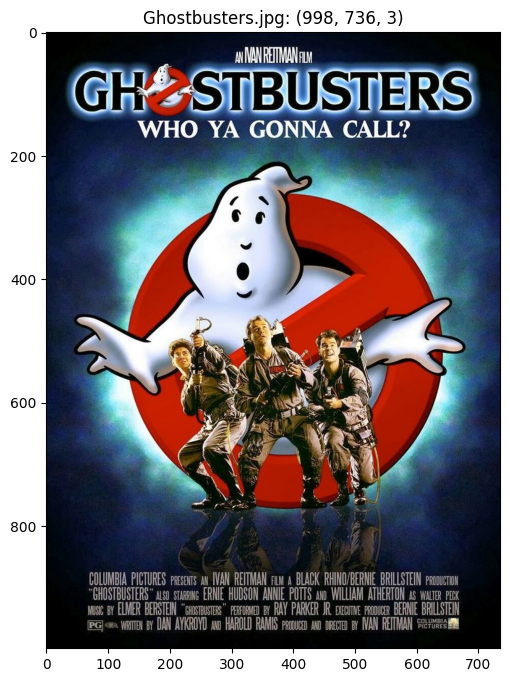

In [3]:
def show_image(img, title='', figsize=(6,6)):
    """
    Display an image with matplotlib.
        
    Parameters:
        img: numpy array - the image to display
        title: str - title for the plot
        figsize: tuple - figure size (width, height)
    """
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(title)
    plt.show()


show_image(image, title=f'{image_name}: {image.shape}', figsize=(8,8))

### Mettre en place un pipeline Albumentations simple

Définissez une composition `test_transform` avec `A.Compose()` qui enchaîne deux transformations : 
- `A.RandomCrop()` pour extraire une sous-région aléatoire de dimensions `height` et `width` égales à la moitié de l'image originale
- `A.HorizontalFlip(p=1)` pour effectuer systématiquement une symétrie horizontale (NB : normalement, on n'utilisera pas p(robabilité)=1, mais plutôt une valeur qui permet d'introduire de l'aléa, comme 0.5)

Appliquez ensuite ce pipeline à l'image de référence en passant celle-ci comme argument `image=`, et récupérez le résultat transformé via la clé `'image'`, puis, pour comprendre l'effet de ces opérations d'augmentation géométrique :
- affichez-là   
- inspectez son type
- sa forme
- la plage de valeurs des pixels.


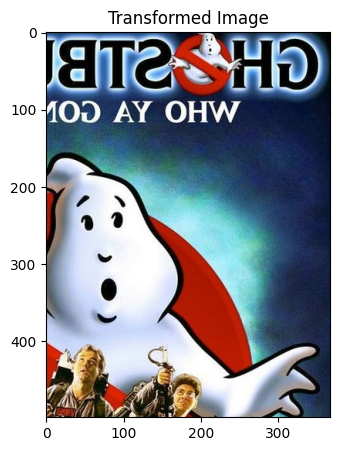

Image type: <class 'numpy.ndarray'>
Transformed image shape: (499, 368, 3)
Pixel value range: [0, 255]


In [15]:
test_transform = A.Compose([
    A.RandomCrop(height=image.shape[0] // 2, width=image.shape[1] // 2), 
    A.HorizontalFlip(p=0.5), # 50% de chance de flip horizontal
])

transformed_data = test_transform(image=image)
transformed_image = transformed_data['image']

show_image(transformed_image, title='Transformed Image', figsize=(5,5))
print('Image type:', type(transformed_image))
print('Transformed image shape:', transformed_image.shape)
print('Pixel value range: [%d, %d]' % (transformed_image.min(), transformed_image.max()))


### Échantillonner plusieurs augmentations

Afin d'observer la diversité générée par le pipeline d'augmentation simple, procédez comme suit :

- Créez une visualisation en grille de **2 lignes × 5 colonnes** avec `matplotlib.pyplot.subplots()`
- Affichez l'**image originale** dans la première case (index 0)
- Générez et affichez **9 variations augmentées** en appliquant `test_transform` de manière répétée à l'image de référence
- Chaque application du pipeline produira une **transformation différente** grâce à l'aléatoire introduit par `RandomCrop`
- Ajoutez des titres appropriés pour distinguer l'originale des versions augmentées
- Utilisez `plt.tight_layout()` pour optimiser l'espacement entre les sous-graphiques

Cette visualisation permet de :
- Constater concrètement l'**effet des transformations géométriques** (recadrage aléatoire et symétrie horizontale)
- Évaluer la **variabilité obtenue** pour enrichir le dataset d'entraînement
- Vérifier que les augmentations introduisent suffisamment de diversité sans dénaturer les images


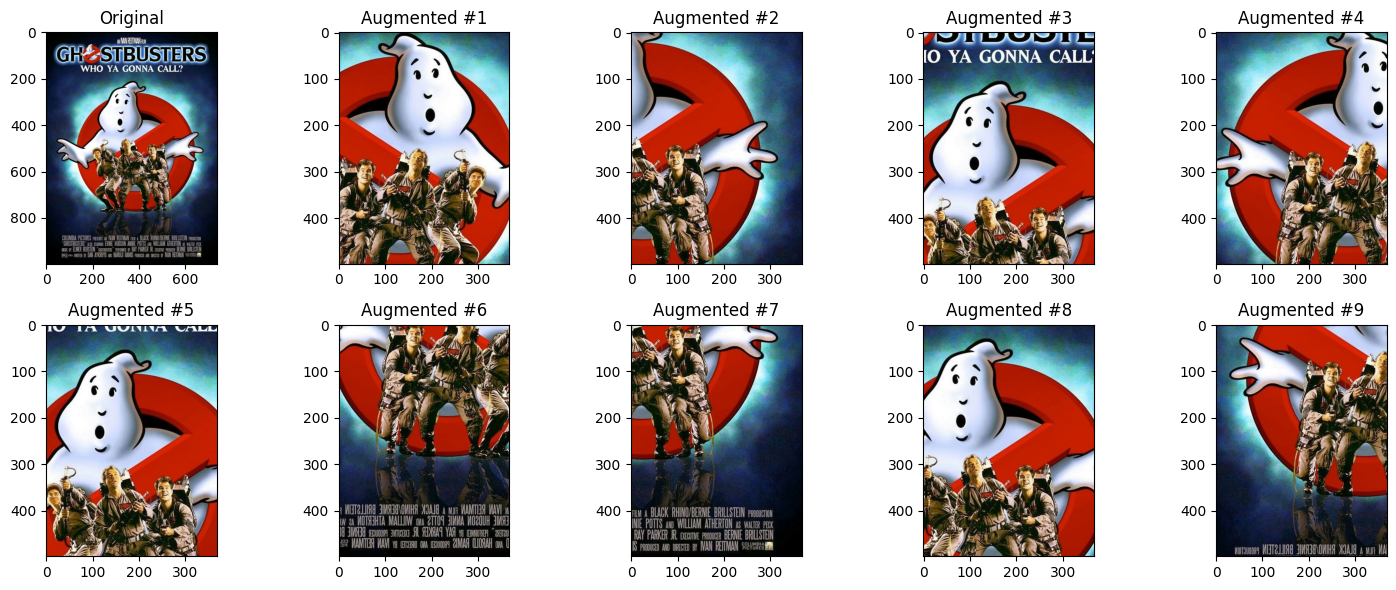

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    if i == 0:
        axes[i].imshow(image)
        axes[i].set_title('Original')
    else:
        transformed = test_transform(image=image)
        aug_img = transformed['image']
        axes[i].imshow(aug_img)
        axes[i].set_title(f'Augmented #{i}')

plt.tight_layout()
plt.show()

### Construire un pipeline de style ImageNet

<span style="color:gray">
<b>Note :</b> <a href="https://www.image-net.org/">ImageNet</a> est un vaste jeu de données de classification d'images contenant plus de 14 millions d'images annotées réparties en plus de 20 000 catégories. Il a servi de référence pour le concours annuel ImageNet Large Scale Visual Recognition Challenge (ILSVRC). Les modèles pré-entraînés sur ImageNet utilisent des valeurs de normalisation standard (moyennes et écarts-types par canal RGB) qui permettent de stabiliser l'entraînement et d'améliorer les performances. Ces statistiques sont devenues une convention largement adoptée pour le prétraitement d'images dans les tâches de classification.
</span>

Définissez un pipeline d'augmentation de style ImageNet en suivant ces étapes : <br>
(cf. [documentation d'Albumentations](https://albumentations.ai/docs/3-basic-usage/image-classification/#imagenet-style-pipeline-rgb-224x224))

- **Définir les paramètres de normalisation ImageNet** : 
    - créez deux tenseurs `MEAN` et `STD` contenant respectivement les moyennes `[0.485, 0.456, 0.406]` et écarts-types `[0.229, 0.224, 0.225]` par canal RGB
- **Concevoir une composition d'augmentations** avec `A.Compose()` incluant :
    - `A.RandomResizedCrop(224, 224)` : recadrage aléatoire avec redimensionnement à 224×224 pixels
    - `A.HorizontalFlip(p=0.5)` : inversion horizontale avec 50% de probabilité
    - `A.ColorJitter()` : variations aléatoires de luminosité, contraste, saturation et teinte
    - `A.Normalize(mean=MEAN, std=STD)` : normalisation des pixels selon les statistiques ImageNet
    - `ToTensorV2()` : conversion finale en tenseur PyTorch au format `(C, H, W)`
- **Tester le pipeline** 
    - Utiliser l'image de référence en passant `image=image` et récupérer le résultat via la clé `'image'`
- **Inspecter le tenseur transformé** en affichant :
    - Son type (doit être `torch.Tensor`)
    - Sa forme (doit être `(3, 224, 224)`)
    - **La plage de valeurs des pixels (généralement entre -2 et +2 après normalisation)**


In [17]:
# https://albumentations.ai/docs/3-basic-usage/image-classification/

MEAN = torch.tensor([0.485, 0.456, 0.406])
STD = torch.tensor([0.229, 0.224, 0.225])

imagenet_train_transforms = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
    A.Normalize(mean=MEAN, std=STD),
    A.ToTensorV2(), # Dans AlbumentationsX : A.ToTensorV2()
])

transformed_data = imagenet_train_transforms(image=image)
transformed_image = transformed_data['image']

print('Image type after transformations:', type(transformed_image))
print('Image shape after transformations:', transformed_image.shape)
print('Pixel value range: [%d, %d]' % (transformed_image.min(), transformed_image.max()))


Image type after transformations: <class 'torch.Tensor'>
Image shape after transformations: torch.Size([3, 224, 224])
Pixel value range: [-1, 2]


### Dénormaliser un tenseur transformé

Implémentez la fonction `denormalize_tensor(tensor_img, mean, std)` qui reconvertit un tenseur `(C, H, W)` normalisé avec `mean`et `std` en image NumPy `uint8`

Testez-la sur `transformed_image` pour vérifier la cohérence de la transformation inverse.

L'image reste transformée, mais **la plage de valeurs des pixels doit avoir repris ses valeurs d'origine**



Image type after denormalization: <class 'numpy.ndarray'>
Image shape after denormalization: (224, 224, 3)
Pixel value range: [11, 224]


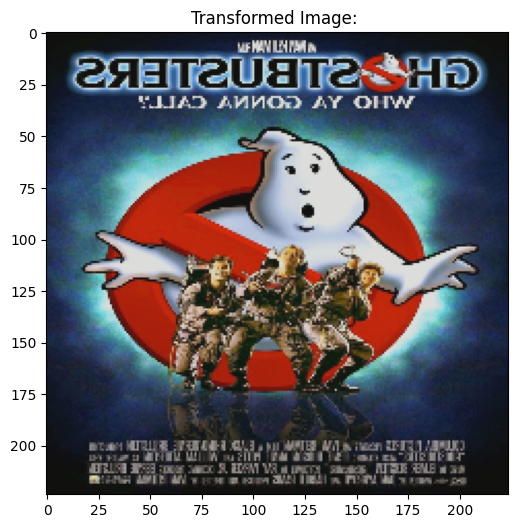

In [18]:
def denormalize_tensor(tensor_img, mean=MEAN, std=STD):
    """
    Dénormalise un tenseur torch (C, H, W) normalisé avec (mean, std) ImageNet
    et retourne une image numpy (H, W, C) en uint8 (0-255).
    """
    t = tensor_img.detach().cpu().clone()
    m = mean.view(1, 1, 3)
    s = std.view(1, 1, 3)
    img = t.permute(1, 2, 0) * s + m
    arr = img.numpy()
    arr = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
    return arr

denormalized = denormalize_tensor(transformed_image)

print('Image type after denormalization:', type(denormalized))
print('Image shape after denormalization:', denormalized.shape)
print('Pixel value range: [%d, %d]' % (denormalized.min(), denormalized.max()))
show_image(denormalized, title='Transformed Image: ')

### Échantillonner plusieurs augmentations avancées

Reprenez la mise en page en grille pour montrer l'image originale et plusieurs instances augmentées issues de `imagenet_train_transforms`, en veillant à dénormaliser les tenseurs avant affichage pour interpréter correctement les variations.


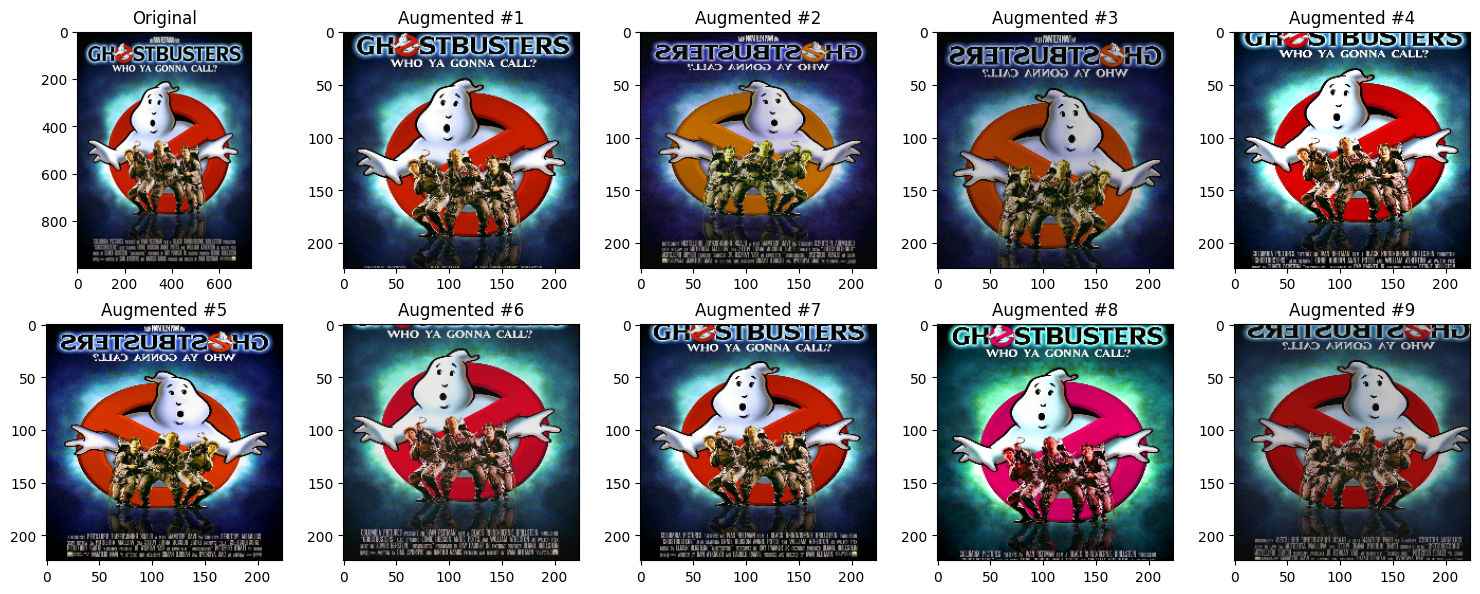

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    if i == 0:
        axes[i].imshow(image)
        axes[i].set_title('Original')
    else:
        transformed = imagenet_train_transforms(image=image)
        aug_img = transformed['image']
        axes[i].imshow(denormalize_tensor(aug_img))
        axes[i].set_title(f'Augmented #{i}')

plt.tight_layout()
plt.show()

### Intégrer le pipeline dans un Dataset PyTorch

Définissez la classe `MyDataset(data_dir, transform)` qui hérite de `torch.utils.data.Dataset` :
- Dans le constructeur `__init__`, listez tous les fichiers d'images du dossier `data_dir` (avec `glob`) et stockez la transformation passée en paramètre.
- Implémentez la méthode `__len__` pour retourner le nombre d'images.
- Implémentez la méthode `__getitem__` pour :
    - Charger l'image à l'index donné avec OpenCV, puis la convertir en RGB.
    - Appliquer la transformation Albumentations `transform` si elle est fournie (`self.transform(image=image)`), puis récupérer l'image transformée via la clé `'image'`.
    - Retourner l'image.


In [20]:
class MyDataset(torch.utils.data.Dataset):
    """
    Custom PyTorch Dataset for loading and transforming images.
        
    Args:
        data_dir (str): Directory path containing image files
        transform (albumentations.Compose, optional): Albumentations transformation pipeline
            
    Returns:
        torch.Tensor or numpy.ndarray: Transformed image (tensor if ToTensorV2 is in pipeline)
    """
    def __init__(self, data_dir, transform=None):
        self.image_files = glob.glob(os.path.join(data_dir, '*.jpg'))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']

        return image

### Construire DataLoader et échantillons augmentés

Instanciez `MyDataset` en lui passant le pipeline ImageNet, créez un `DataLoader` avec `shuffle=True`.

NB : le dataset est petit, on peut tout charger (`batchsize`) en une fois.


In [21]:
my_dataset = MyDataset(data_dir=data_dir, transform=imagenet_train_transforms)
dataloader = torch.utils.data.DataLoader(my_dataset, batch_size=len(my_dataset), shuffle=True, num_workers=4)

print(f'Dataset size: {len(my_dataset)}')
print(f'Number of batches: {len(dataloader)}')

Dataset size: 6
Number of batches: 1


### Observer les batchs augmentés

Itérez sur plusieurs époques en parcourant le `DataLoader` (commen on le ferait lorst d'un entraînement) :
- Affichez la forme des tenseurs renvoyés
- Visualisez, le lot d'images fournies afin d'évaluer la variété introduite par les augmentations successives générées par le dataset (et son `__getitem__`)


Epoch 1/5
  Batch 1: torch.Size([6, 3, 224, 224])


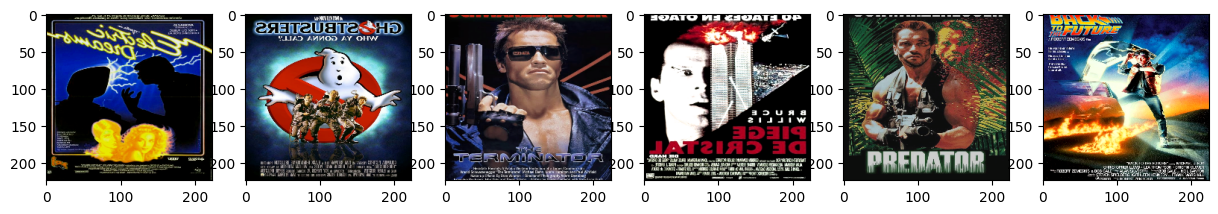

Epoch 2/5
  Batch 1: torch.Size([6, 3, 224, 224])


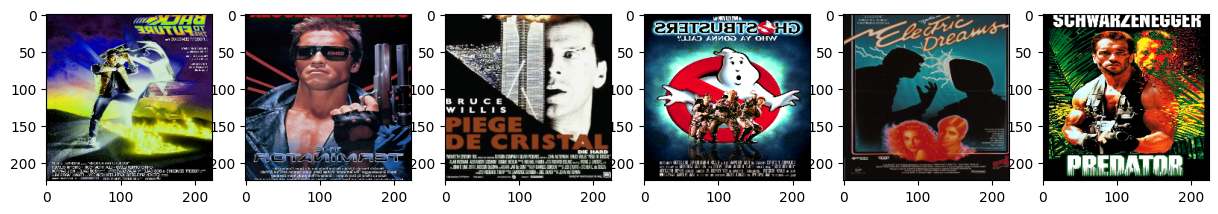

Epoch 3/5
  Batch 1: torch.Size([6, 3, 224, 224])


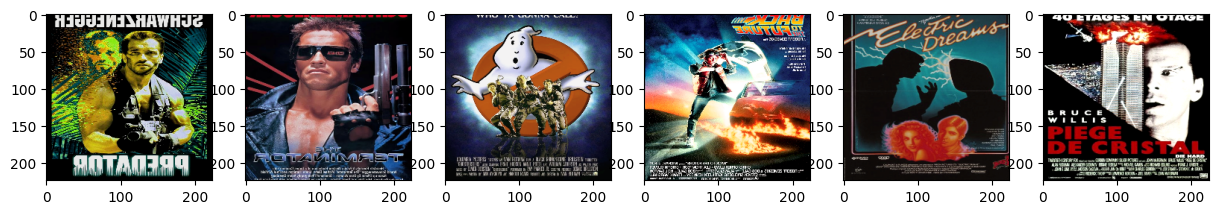

Epoch 4/5
  Batch 1: torch.Size([6, 3, 224, 224])


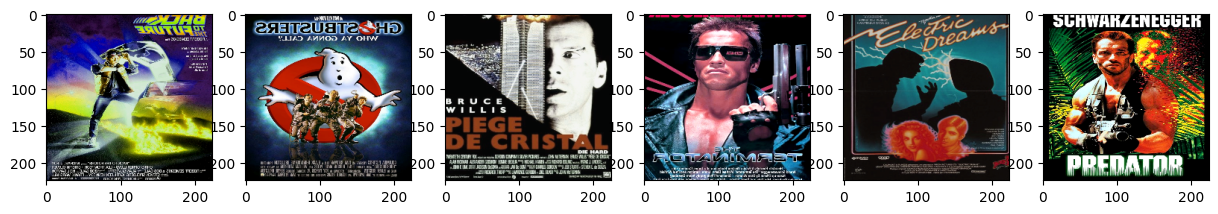

Epoch 5/5
  Batch 1: torch.Size([6, 3, 224, 224])


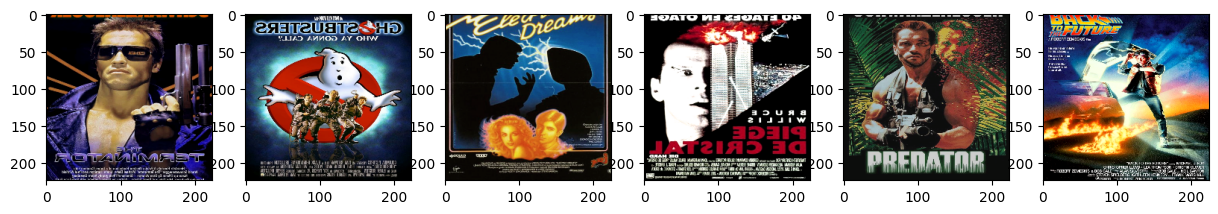

In [24]:
epochs = 5

batch_size = len(my_dataset)
for epoch in range(epochs):
    print(f'Epoch {epoch+1}/{epochs}')
    for batch_idx, images in enumerate(dataloader):
        print(f'  Batch {batch_idx+1}:', images.shape)
        
    fig, axes = plt.subplots(1, batch_size, figsize=(15, 4))
    axes = axes.flatten()    
    for i in range(batch_size):
        denormalized_img = denormalize_tensor(images[i])
        axes[i].imshow(denormalized_img)
        
    plt.show()

### Prolonger l'exploration d'augmentations

Expérimenter d'autres combinaisons Albumentations, ajuster les paramètres, ajouter des transformations géométriques supplémentaires, ...
